In [ ]:
# ============================================================
# STOCK MARKET PRICE PREDICTION
# BiLSTM + GRU Hybrid Model | 10 Stocks | 10 Years of Data
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, GRU, Dense, Dropout, Input,
    Bidirectional, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import timedelta
import pickle
import os

# ── Google Drive folder containing all 10 CSV files ───────
DRIVE_PATH = '/content/drive/MyDrive/Colab Notebooks/data1010'

# ── Stock tickers and their CSV filenames ─────────────────
TICKERS = {
    'AAPL'  : 'AAPL_daily_10yr.csv',
    'AMZN'  : 'AMZN_daily_10yr.csv',
    'BAC'   : 'BAC_daily_10yr.csv',
    'BLK'   : 'BLK_daily_10yr.csv',
    'GOOGL' : 'GOOGL_daily_10yr.csv',
    'JPM'   : 'JPM_daily_10yr.csv',
    'META'  : 'META_daily_10yr.csv',
    'MSFT'  : 'MSFT_daily_10yr.csv',
    'NVDA'  : 'NVDA_daily_10yr.csv',
    'TSLA'  : 'TSLA_daily_10yr.csv',
}

# ── Feature columns the model trains on ───────────────────
FEATURE_COLS = [
    'Close',           # prediction target (col 0)
    'Log_Returns',     # daily % change
    'RSI_14',          # momentum — overbought/oversold
    'EMA_ratio',       # short vs medium term trend
    'Volume_ratio',    # unusual trading activity
    'Volatility_20',   # how choppy the stock has been
    'MACD_signal',     # momentum shift signal
    'ATR_ratio',       # typical daily price range
    'Momentum_5',      # where price is vs 5 days ago
    'Return_Direction', # was yesterday up or down
]

LOOKBACK    = 90    # days of history the model sees at once
TRAIN_RATIO = 0.8   # 80% training, 20% test

print("Setup complete.")
print(f"Drive path : {DRIVE_PATH}")
print(f"Stocks     : {list(TICKERS.keys())}")
print(f"Features   : {len(FEATURE_COLS)}")
print(f"Lookback   : {LOOKBACK} days")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete.
Drive path : /content/drive/MyDrive/Colab Notebooks/data1010
Stocks     : ['AAPL', 'AMZN', 'BAC', 'BLK', 'GOOGL', 'JPM', 'META', 'MSFT', 'NVDA', 'TSLA']
Features   : 10
Lookback   : 60 days


In [ ]:
# ============================================================
# CELL 2 — FEATURE ENGINEERING
#
# Takes raw Yahoo Finance OHLCV columns and builds 10
# scale-independent features that work across all stocks.
#
# We use Adj Close (not Close) as the price base because
# it accounts for stock splits over 10 years of history.
# ============================================================

def build_features(df):
    close  = df['Adj Close']
    high   = df['High']
    low    = df['Low']
    volume = df['Volume']

    out = pd.DataFrame(index=df.index)

    # 1. Close — the prediction target
    out['Close'] = close

    # 2. Log Returns — daily % change, scale-free across stocks
    out['Log_Returns'] = np.log(close / close.shift(1))

    # 3. RSI 14 — momentum, always 0–100
    delta = close.diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    out['RSI_14'] = 100 - (100 / (1 + gain / loss))

    # 4. EMA ratio — trend direction without raw dollar values
    #    > 1.0 = short-term trend above medium-term (bullish)
    #    < 1.0 = short-term trend below medium-term (bearish)
    ema_9  = close.ewm(span=9,  adjust=False).mean()
    ema_20 = close.ewm(span=20, adjust=False).mean()
    out['EMA_ratio'] = ema_9 / ema_20

    # 5. Volume ratio — today vs own 20-day average
    #    2.0 = twice as busy as usual (same meaning any stock)
    out['Volume_ratio'] = volume / volume.rolling(20).mean()

    # 6. Volatility — 20-day rolling std of log returns
    #    tells the model how choppy this stock has been lately
    out['Volatility_20'] = out['Log_Returns'].rolling(20).std()

    # 7. MACD signal — momentum divergence, divided by price
    #    to make it scale-free across different price levels
    ema_12 = close.ewm(span=12, adjust=False).mean()
    ema_26 = close.ewm(span=26, adjust=False).mean()
    macd   = ema_12 - ema_26
    signal = macd.ewm(span=9, adjust=False).mean()
    out['MACD_signal'] = (macd - signal) / close

    # 8. ATR ratio — intraday range as % of price
    #    captures how much the stock typically swings each day
    prev_close = close.shift(1)
    true_range = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low  - prev_close).abs()
    ], axis=1).max(axis=1)
    out['ATR_ratio'] = true_range.rolling(14).mean() / close

    # 9. Momentum 5 — price vs 5 days ago as a %
    #    gives the model explicit short-term direction context
    out['Momentum_5'] = (close - close.shift(5)) / close.shift(5)

    # 10. Return Direction — was yesterday positive or negative
    #     simple +1/-1 flag that helps kill the lag problem
    out['Return_Direction'] = np.sign(out['Log_Returns'].shift(1))

    out.dropna(inplace=True)
    return out


print("Feature engineering function ready.")
print(f"Will produce {len(FEATURE_COLS)} features per trading day.")

Feature engineering function ready.
Will produce 10 features per trading day.


In [ ]:
# ============================================================
# CELL 3 — LOAD ALL 10 STOCKS & BUILD TRAINING DATA
#
# Key design decisions:
#
# 1. Split BEFORE scaling (no data leakage)
#    The scaler only sees training data — if it saw the full
#    dataset it would know future price ranges and give the
#    model an unfair advantage during training.
#
# 2. One scaler per stock
#    AAPL and BLK trade at very different price levels.
#    Each stock needs its own scaler so they normalise
#    independently into the same [0,1] range.
#
# 3. Split per stock THEN combine
#    Each stock contributes its own 80% training and 20%
#    test sequences. Only the training portions are shuffled
#    together — test sets stay in chronological order.
# ============================================================

def prepare_single_stock(file_path, lookback=LOOKBACK):
    df = pd.read_csv(file_path, index_col=0)
    df.index = pd.to_datetime(df.index)

    # Build 10 features from raw OHLCV
    df = build_features(df)
    data = df[FEATURE_COLS].values

    # Step 1 — split BEFORE scaling
    split     = int(len(data) * TRAIN_RATIO)
    train_raw = data[:split]
    test_raw  = data[split:]

    # Step 2 — fit scaler on training data only
    scaler       = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_raw)
    test_scaled  = scaler.transform(test_raw)

    full_scaled = np.vstack((train_scaled, test_scaled))

    # Step 3 — build 60-day sliding windows
    # Each X = 60 days × 10 features
    # Each y = next day's scaled Close price
    X, y = [], []
    for i in range(lookback, len(full_scaled)):
        X.append(full_scaled[i - lookback:i])
        y.append(full_scaled[i, 0])   # Close = column 0

    X, y = np.array(X), np.array(y)

    # Step 4 — keep this stock's train/test split intact
    train_samples = split - lookback
    return (
        X[:train_samples], X[train_samples:],
        y[:train_samples], y[train_samples:],
        scaler, df
    )


# ── Load all 10 stocks ────────────────────────────────────
all_X_train, all_X_test = [], []
all_y_train, all_y_test = [], []
scalers = {}   # one scaler per ticker
dfs     = {}   # one dataframe per ticker

print("Loading and processing stocks...\n")

for ticker, filename in TICKERS.items():
    file_path = os.path.join(DRIVE_PATH, filename)

    if not os.path.exists(file_path):
        print(f"  SKIPPED {ticker} — file not found at {file_path}")
        continue

    X_tr, X_te, y_tr, y_te, scaler, df = prepare_single_stock(file_path)

    all_X_train.append(X_tr)
    all_X_test.append(X_te)
    all_y_train.append(y_tr)
    all_y_test.append(y_te)
    scalers[ticker] = scaler
    dfs[ticker]     = df

    print(f"  {ticker:6s}  rows: {len(df):5d}  "
          f"train: {len(X_tr):4d}  test: {len(X_te):4d}")

# Combine all stocks
X_train = np.concatenate(all_X_train, axis=0)
X_test  = np.concatenate(all_X_test,  axis=0)
y_train = np.concatenate(all_y_train, axis=0)
y_test  = np.concatenate(all_y_test,  axis=0)

# Shuffle ONLY the training data so the model sees
# a mix of all stocks each batch — not one stock at a time
idx = np.random.permutation(len(X_train))
X_train, y_train = X_train[idx], y_train[idx]

print(f"\nStocks loaded        : {list(scalers.keys())}")
print(f"Combined train shape : {X_train.shape}")
print(f"Combined test shape  : {X_test.shape}")
print(f"  → {X_train.shape[0]} training sequences")
print(f"  → {X_train.shape[1]} days lookback")
print(f"  → {X_train.shape[2]} features per day")

Loading and processing stocks...

  AAPL    rows:  2495  train: 1936  test:  499
  AMZN    rows:  2495  train: 1936  test:  499
  BAC     rows:  2495  train: 1936  test:  499
  BLK     rows:  2495  train: 1936  test:  499
  GOOGL   rows:  2495  train: 1936  test:  499
  JPM     rows:  2495  train: 1936  test:  499
  META    rows:  2495  train: 1936  test:  499
  MSFT    rows:  2495  train: 1936  test:  499
  NVDA    rows:  2495  train: 1936  test:  499
  TSLA    rows:  2495  train: 1936  test:  499

Stocks loaded        : ['AAPL', 'AMZN', 'BAC', 'BLK', 'GOOGL', 'JPM', 'META', 'MSFT', 'NVDA', 'TSLA']
Combined train shape : (19360, 60, 10)
Combined test shape  : (4990, 60, 10)
  → 19360 training sequences
  → 60 days lookback
  → 10 features per day


In [ ]:
# ============================================================
# CELL 4 — MODEL ARCHITECTURE
#
# BiLSTM (128 units)
#   Reads the 60-day window forwards AND backwards.
#   Gives the model both historical trend context and
#   recent pattern awareness at the same time.
#   L2 regularisation prevents memorising training stocks.
#
# GRU layer 1 (64 units)
#   Lighter than LSTM, better at catching short-term
#   sharp movements. Extracts medium-term patterns.
#
# GRU layer 2 (32 units)
#   Sharpens the representation into a compact summary
#   before the dense layers make the final prediction.
#
# Dense layers
#   Two layers gradually compress to a single output:
#   the predicted next-day Close price (scaled 0–1).
# ============================================================

def build_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),

        # BiLSTM — bidirectional context extraction
        Bidirectional(LSTM(
            units=128,
            return_sequences=True,
            kernel_regularizer=l2(1e-4)
        )),
        BatchNormalization(),
        Dropout(0.3),

        # GRU 1 — medium-term pattern extraction
        GRU(units=64,
            return_sequences=True,
            kernel_regularizer=l2(1e-4)),
        Dropout(0.2),

        # GRU 2 — final feature sharpening
        GRU(units=32, return_sequences=False),
        Dropout(0.2),

        # Dense layers — decision making
        Dense(units=32, activation='relu'),
        Dense(units=16, activation='relu'),

        # Output — single predicted price (scaled)
        Dense(units=1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss=tf.keras.losses.Huber()
        # Huber loss is more robust than MSE for stock data
        # because sharp price spikes don't distort training
    )

    model.summary()
    return model


model = build_model((X_train.shape[1], X_train.shape[2]))

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_4 (Bidirectional) │ (None, 60, 256)        │       142,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 60, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 60, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_6 (GRU)                     │ (None, 60, 64)         │        61,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_7 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 216,193 (844.50 KB)

 Trainable params: 215,681 (842.50 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/100
605/605 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - loss: 0.0323 - val_loss: 0.1029 - learning_rate: 1.0000e-04
Epoch 2/100
605/605 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 0.0194 - val_loss: 0.0908 - learning_rate: 2.8000e-04
Epoch 3/100
605/605 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 0.0107 - val_loss: 0.0830 - learning_rate: 4.6000e-04
Epoch 4/100
605/605 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - loss: 0.0062 - val_loss: 0.0796 - learning_rate: 6.4000e-04
Epoch 5/100
605/605 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - loss: 0.0035 - val_loss: 0.0772 - learning_rate: 8.2000e-04
Epoch 6/100
605/605 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.0022 - val_loss: 0.0694 - learning_rate: 8.2000e-04
Epoch 7/100
605/605 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - loss: 0.0013 - val_loss: 0.0588 - learning_rate: 8.2000e-04
Epoch 8/100
605/605 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - loss: 9.3212e-04 - val_loss: 0.0678 - learning_rate: 8.2000e-04
Epoch 9/100
605/605 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - los

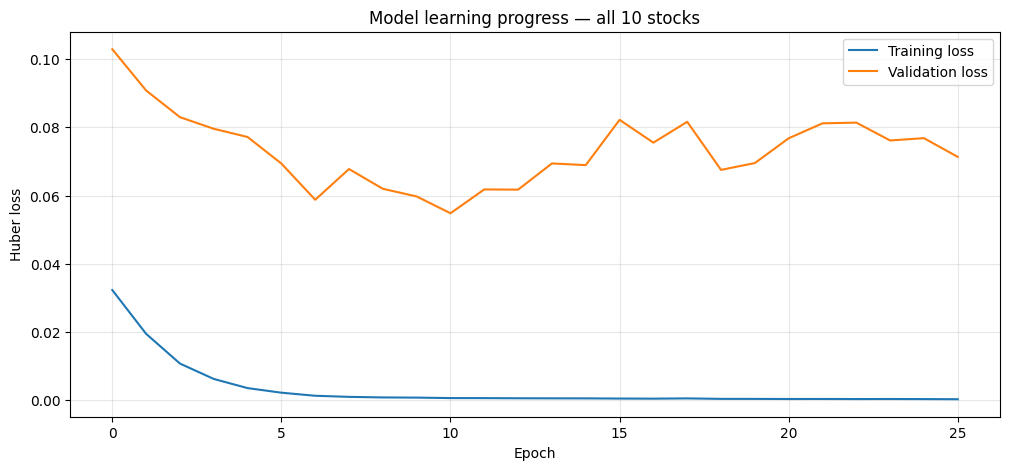

In [ ]:
# ============================================================
# CELL 5 — TRAINING
#
# Learning rate warmup:
#   Starts low (0.0001) and ramps to 0.001 over 5 epochs.
#   Prevents bad early weight updates that the model
#   never fully recovers from.
#
# EarlyStopping:
#   Monitors validation loss. Stops training when it stops
#   improving and restores the best weights automatically.
#   Prevents overfitting without guessing the epoch count.
#
# ReduceLROnPlateau:
#   Halves the learning rate when training stalls.
#   Lets the model make large updates early and fine-tune
#   carefully as it converges.
# ============================================================

def lr_warmup_schedule(epoch, lr):
    warmup_epochs = 5
    initial_lr    = 0.0001
    target_lr     = 0.001
    if epoch < warmup_epochs:
        return initial_lr + (target_lr - initial_lr) * (epoch / warmup_epochs)
    return lr

lr_warmup = tf.keras.callbacks.LearningRateScheduler(
    lr_warmup_schedule, verbose=0
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_test, y_test),
    callbacks=[lr_warmup, reduce_lr, early_stop],
    shuffle=True,
    verbose=1
)

# Training curve
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'],     label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Model learning progress — all 10 stocks')
plt.xlabel('Epoch')
plt.ylabel('Huber loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

  PER-STOCK PERFORMANCE REPORT

  AAPL
    MAE              : $33.32
    RMSE             : $37.18
    Price accuracy   : 85.98%
    Direction acc    : 52.61%

  AMZN
    MAE              : $25.65
    RMSE             : $28.25
    Price accuracy   : 88.06%
    Direction acc    : 49.80%

  BAC
    MAE              : $3.65
    RMSE             : $4.38
    Price accuracy   : 92.24%
    Direction acc    : 53.01%

  BLK
    MAE              : $110.55
    RMSE             : $127.91
    Price accuracy   : 89.14%
    Direction acc    : 53.01%

  GOOGL
    MAE              : $47.91
    RMSE             : $67.09
    Price accuracy   : 80.24%
    Direction acc    : 52.61%

  JPM
    MAE              : $58.69
    RMSE             : $68.21
    Price accuracy   : 78.41%
    Direction acc    : 51.61%

  META
    MAE              : $99.41
    RMSE             : $114.50
    Price accuracy   : 84.71%
    Direction acc    : 50.40%

  MSFT
    MAE              : $45.74
    RMSE             : $50.89
    Pr

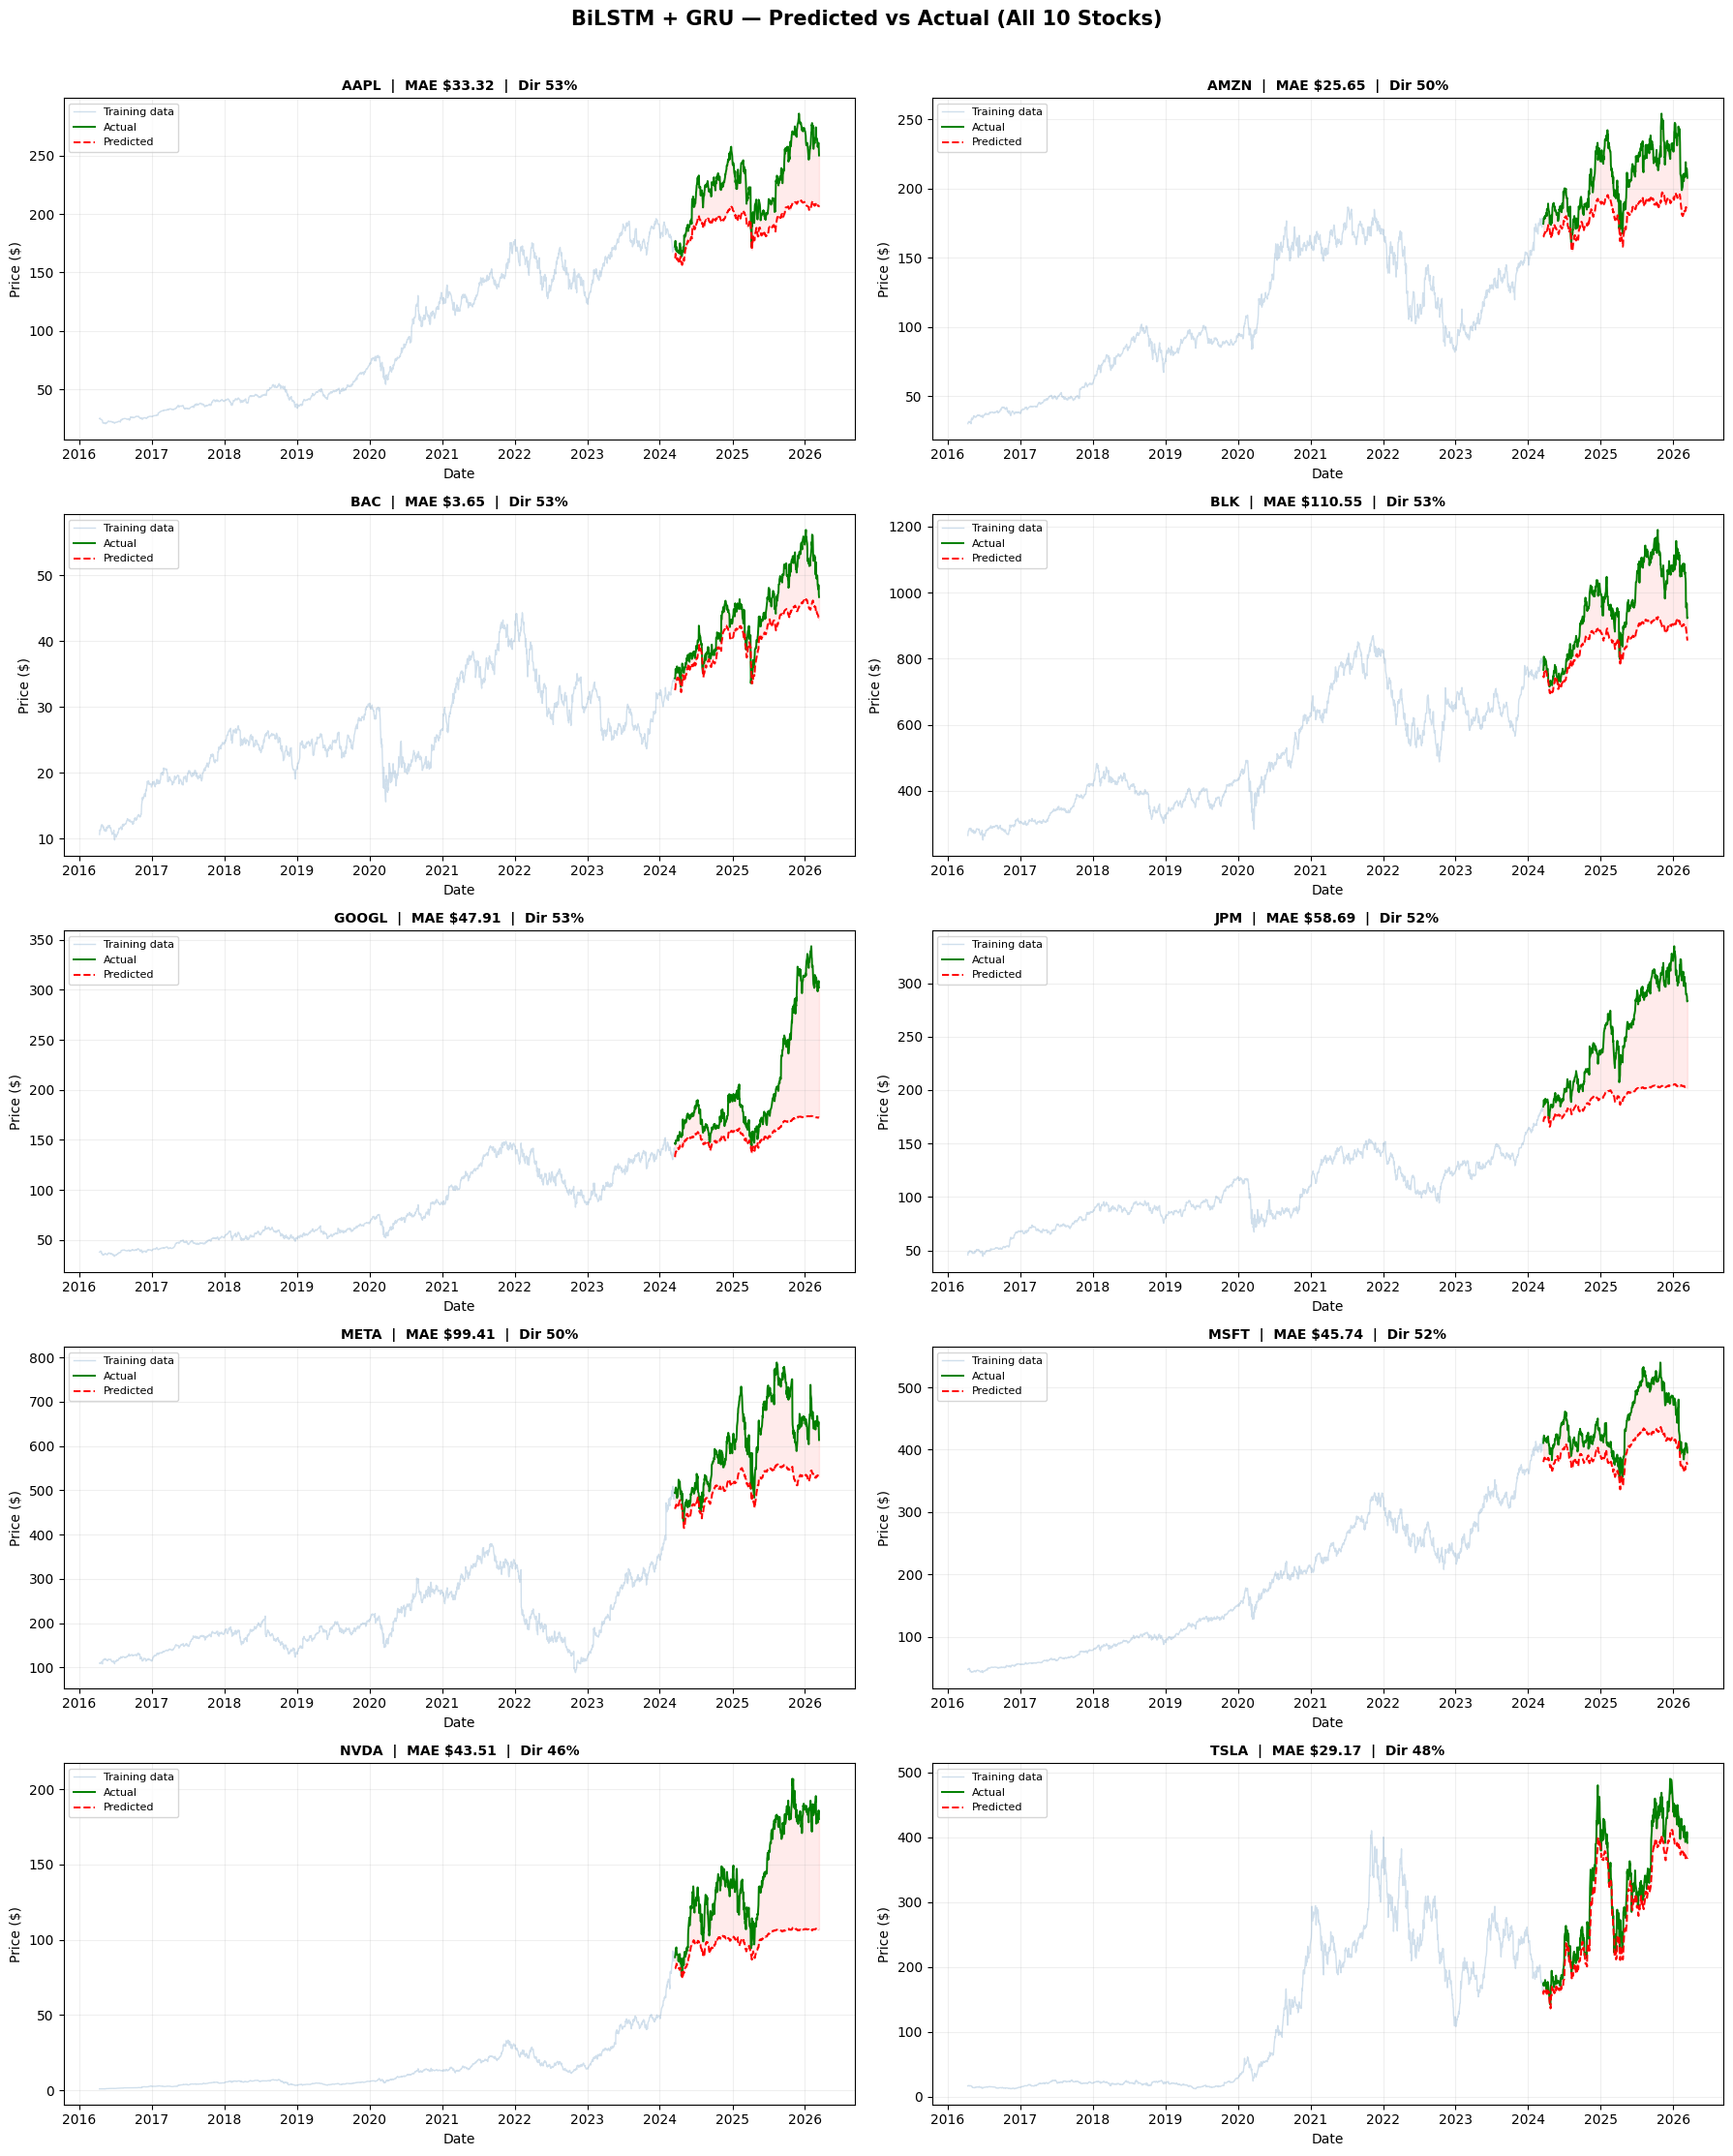


  SUMMARY — RANKED BY MAE
       MAE ($)  RMSE ($)  Accuracy (%)  Direction Acc (%)
BAC       3.65      4.38         92.24               53.0
AMZN     25.65     28.25         88.06               49.8
TSLA     29.17     34.24         91.18               48.4
AAPL     33.32     37.18         85.98               52.6
NVDA     43.51     50.57         72.13               45.8
MSFT     45.74     50.89         90.01               52.0
GOOGL    47.91     67.09         80.24               52.6
JPM      58.69     68.21         78.41               51.6
META     99.41    114.50         84.71               50.4
BLK     110.55    127.91         89.14               53.0

  Average MAE  : $49.76
  Average RMSE : $58.32
  Average Dir  : 50.9%


In [ ]:
# ============================================================
# CELL 6 — EVALUATION
#
# Reports 4 metrics per stock:
#   MAE ($)      — average dollar error per prediction
#   RMSE ($)     — penalises large errors more than MAE
#   Accuracy (%) — how close predictions are as a % of price
#   Direction (%)— did the model call UP/DOWN correctly
#
# Produces a 5×2 chart grid showing predicted vs actual
# price for every stock, plus a ranked summary table.
# ============================================================

def evaluate_all_stocks(model, scalers, dfs):
    results = {}

    fig, axes = plt.subplots(5, 2, figsize=(18, 22))
    axes = axes.flatten()

    print("=" * 55)
    print("  PER-STOCK PERFORMANCE REPORT")
    print("=" * 55)

    for idx, (ticker, scaler) in enumerate(scalers.items()):
        df    = dfs[ticker]
        fpath = os.path.join(DRIVE_PATH, TICKERS[ticker])

        # Rebuild this stock's test sequences
        _, X_te, _, y_te, _, _ = prepare_single_stock(fpath)

        num_features = scaler.n_features_in_

        def rescale(vals):
            dummy        = np.zeros((len(vals), num_features))
            dummy[:, 0]  = vals   # Close = column 0
            return scaler.inverse_transform(dummy)[:, 0]

        y_pred_scaled = model.predict(X_te, verbose=0).flatten()
        y_pred        = rescale(y_pred_scaled)
        y_true        = rescale(y_te)

        mae     = mean_absolute_error(y_true, y_pred)
        rmse    = np.sqrt(mean_squared_error(y_true, y_pred))
        mape    = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        dir_acc = np.mean(
            np.sign(np.diff(y_true)) == np.sign(np.diff(y_pred))
        ) * 100

        results[ticker] = {
            'MAE ($)'          : round(mae,  2),
            'RMSE ($)'         : round(rmse, 2),
            'Accuracy (%)'     : round(100 - mape, 2),
            'Direction Acc (%)': round(dir_acc, 1),
        }

        print(f"\n  {ticker}")
        print(f"    MAE              : ${mae:.2f}")
        print(f"    RMSE             : ${rmse:.2f}")
        print(f"    Price accuracy   : {100 - mape:.2f}%")
        print(f"    Direction acc    : {dir_acc:.2f}%")

        # Chart
        test_dates = df.index[-len(y_true):]
        ax         = axes[idx]

        ax.plot(df.index[:-len(y_true)],
                df['Close'].iloc[:-len(y_true)],
                color='steelblue', alpha=0.25,
                linewidth=1, label='Training data')
        ax.plot(test_dates, y_true,
                color='green', linewidth=1.4, label='Actual')
        ax.plot(test_dates, y_pred,
                color='red', linewidth=1.4,
                linestyle='dashed', label='Predicted')
        ax.fill_between(test_dates, y_true, y_pred,
                        alpha=0.08, color='red')
        ax.set_title(
            f"{ticker}  |  MAE ${mae:.2f}  |  Dir {dir_acc:.0f}%",
            fontsize=10, fontweight='bold'
        )
        ax.set_xlabel('Date')
        ax.set_ylabel('Price ($)')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.2)

    plt.suptitle(
        'BiLSTM + GRU — Predicted vs Actual (All 10 Stocks)',
        fontsize=15, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.show()

    # Summary table
    df_results = pd.DataFrame(results).T.sort_values('MAE ($)')

    print("\n" + "=" * 55)
    print("  SUMMARY — RANKED BY MAE")
    print("=" * 55)
    print(df_results.to_string())
    print(f"\n  Average MAE  : ${df_results['MAE ($)'].mean():.2f}")
    print(f"  Average RMSE : ${df_results['RMSE ($)'].mean():.2f}")
    print(f"  Average Dir  : "
          f"{df_results['Direction Acc (%)'].mean():.1f}%")

    return results


results = evaluate_all_stocks(model, scalers, dfs)

In [ ]:
# ============================================================
# CELL 8 — NEXT-DAY PREDICTION
#
# Change PREDICT_TICKER to any of the 10 loaded stocks.
# Available: AAPL  AMZN  BAC  BLK  GOOGL
#            JPM   META  MSFT NVDA  TSLA
# ============================================================

PREDICT_TICKER = 'AAPL'

def predict_next_day(ticker, model, scalers, dfs):
    if ticker not in scalers:
        print(f"'{ticker}' not found.")
        print(f"Available: {list(scalers.keys())}")
        return

    scaler    = scalers[ticker]
    file_path = os.path.join(DRIVE_PATH, TICKERS[ticker])

    df_raw = pd.read_csv(file_path, index_col=0)
    df_raw.index = pd.to_datetime(df_raw.index)
    df_feat = build_features(df_raw)

    # Take the last 60 days, scale, and reshape for the model
    recent = df_feat[FEATURE_COLS].tail(LOOKBACK).values
    scaled = scaler.transform(recent).reshape(
        1, LOOKBACK, len(FEATURE_COLS)
    )

    # Predict scaled Close, inverse-transform to dollars
    pred_scaled = model.predict(scaled, verbose=0)[0, 0]
    dummy       = np.zeros((1, scaler.n_features_in_))
    dummy[0, 0] = pred_scaled
    next_price  = scaler.inverse_transform(dummy)[0, 0]

    last_close = df_feat['Close'].iloc[-1]
    last_date  = df_feat.index[-1]
    change     = next_price - last_close
    direction  = "UP" if change > 0 else "DOWN"

    # Find next trading day (skip weekends)
    next_date = last_date + timedelta(days=1)
    while next_date.weekday() >= 5:
        next_date += timedelta(days=1)

    print("=" * 46)
    print(f"  NEXT-DAY PREDICTION — {ticker}")
    print("=" * 46)
    print(f"  Data up to  :  {last_date.strftime('%Y-%m-%d')}")
    print(f"  Predicting  :  {next_date.strftime('%Y-%m-%d')}")
    print(f"  Last close  :  ${last_close:.2f}")
    print(f"  Predicted   :  ${next_price:.2f}")
    print(f"  Direction   :  {direction}  ${abs(change):.2f}")
    print("=" * 46)
    return next_price


predict_next_day(PREDICT_TICKER, model, scalers, dfs)

  NEXT-DAY PREDICTION — AAPL
  Data up to  :  2026-03-13
  Predicting  :  2026-03-16
  Last close  :  $250.12
  Predicted   :  $204.93
  Direction   :  DOWN  $45.19


np.float64(204.9340982246697)

  2-WEEK FORECAST — AAPL
  Last close (2026-03-13) : $250.12
--------------------------------------------------
  Date            Predicted     Change   Dir
--------------------------------------------------
  2026-03-16     $  204.93  ▼ $ 45.19
  2026-03-17     $  199.43  ▼ $  5.51
  2026-03-18     $  194.71  ▼ $  4.71
  2026-03-19     $  190.28  ▼ $  4.44
  2026-03-20     $  186.07  ▼ $  4.21
  2026-03-23     $  182.01  ▼ $  4.05
  2026-03-24     $  178.10  ▼ $  3.91
  2026-03-25     $  174.33  ▼ $  3.78
  2026-03-26     $  170.66  ▼ $  3.67
  2026-03-27     $  167.11  ▼ $  3.55
--------------------------------------------------
  2-week outlook : DOWN  $83.01 total


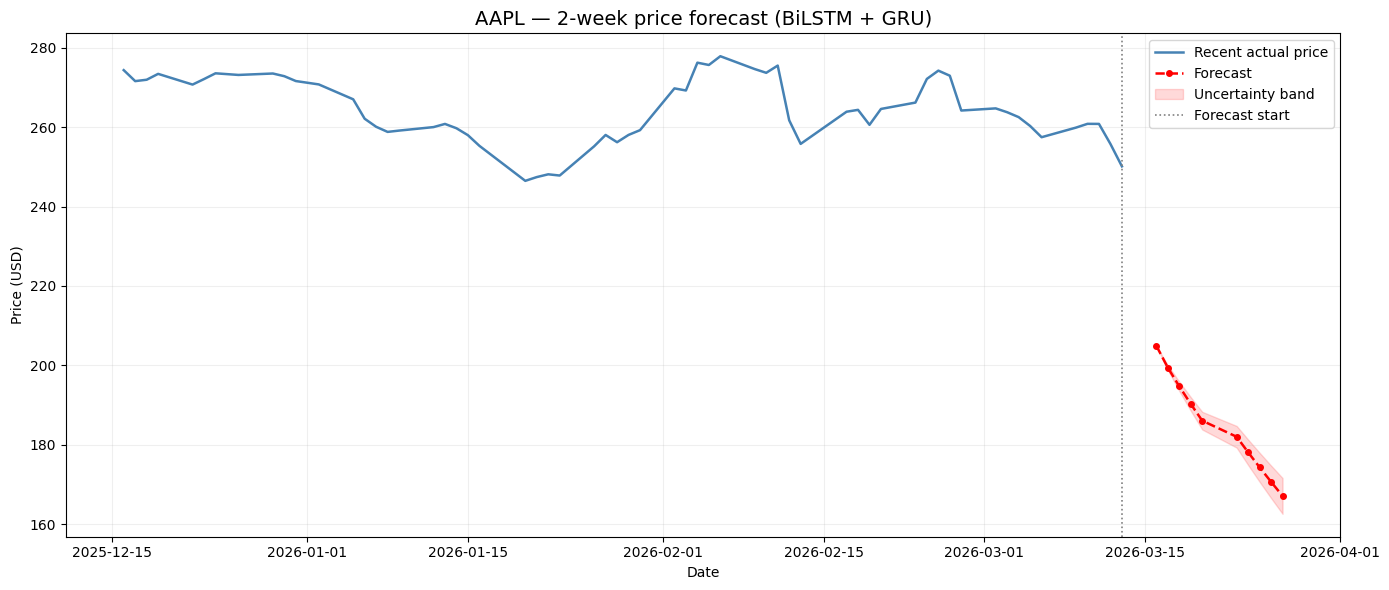

(array([204.93409822, 199.42632421, 194.71493691, 190.27848853,
        186.06526525, 182.01073983, 178.10344821, 174.32765866,
        170.65938661, 167.11425916]),
 [Timestamp('2026-03-16 00:00:00'),
  Timestamp('2026-03-17 00:00:00'),
  Timestamp('2026-03-18 00:00:00'),
  Timestamp('2026-03-19 00:00:00'),
  Timestamp('2026-03-20 00:00:00'),
  Timestamp('2026-03-23 00:00:00'),
  Timestamp('2026-03-24 00:00:00'),
  Timestamp('2026-03-25 00:00:00'),
  Timestamp('2026-03-26 00:00:00'),
  Timestamp('2026-03-27 00:00:00')])

In [ ]:
# ============================================================
# CELL 9 — 2-WEEK FORECAST
#
# Change FORECAST_TICKER to any of the 10 loaded stocks.
# Available: AAPL  AMZN  BAC  BLK  GOOGL
#            JPM   META  MSFT NVDA  TSLA
#
# Note on reliability:
# Day 1–3 predictions are most reliable. By day 10 the
# uncertainty band is wide because each prediction builds
# on the previous one's error. Use as a directional guide,
# not precise price targets.
# ============================================================

FORECAST_TICKER = 'AAPL'

def predict_two_weeks(ticker, model, scalers, days=10):
    if ticker not in scalers:
        print(f"'{ticker}' not found.")
        print(f"Available: {list(scalers.keys())}")
        return

    scaler    = scalers[ticker]
    file_path = os.path.join(DRIVE_PATH, TICKERS[ticker])

    df_raw = pd.read_csv(file_path, index_col=0)
    df_raw.index = pd.to_datetime(df_raw.index)
    df_feat = build_features(df_raw)

    last_date  = df_feat.index[-1]
    last_close = df_feat['Close'].iloc[-1]

    # Seed the window with the last 60 known days
    window = scaler.transform(
        df_feat[FEATURE_COLS].tail(LOOKBACK).values
    ).reshape(1, LOOKBACK, len(FEATURE_COLS))

    future_scaled = []

    for _ in range(days):
        pred = model.predict(window, verbose=0)[0, 0]
        future_scaled.append(pred)

        # Slide window: update Close (col 0),
        # keep other features from last known day
        next_row    = window[0, -1, :].copy()
        next_row[0] = pred
        window = np.append(
            window[:, 1:, :],
            next_row.reshape(1, 1, -1),
            axis=1
        )

    # Inverse-transform all predictions at once
    dummy        = np.zeros((days, scaler.n_features_in_))
    dummy[:, 0]  = future_scaled
    predicted_prices = scaler.inverse_transform(dummy)[:, 0]

    # Generate future trading dates (skip weekends)
    future_dates = []
    current      = last_date
    while len(future_dates) < days:
        current += timedelta(days=1)
        if current.weekday() < 5:
            future_dates.append(current)

    # Print forecast table
    print("=" * 50)
    print(f"  2-WEEK FORECAST — {ticker}")
    print("=" * 50)
    print(f"  Last close "
          f"({last_date.strftime('%Y-%m-%d')}) : ${last_close:.2f}")
    print("-" * 50)
    print(f"  {'Date':<14} {'Predicted':>10} "
          f"{'Change':>10}  {'Dir':>4}")
    print("-" * 50)

    prev = last_close
    for date, price in zip(future_dates, predicted_prices):
        change    = price - prev
        direction = "▲" if change >= 0 else "▼"
        print(f"  {date.strftime('%Y-%m-%d'):<14} "
              f"${price:>8.2f}  "
              f"{direction} ${abs(change):>6.2f}")
        prev = price

    print("-" * 50)
    total   = predicted_prices[-1] - last_close
    outlook = "UP" if total >= 0 else "DOWN"
    print(f"  2-week outlook : {outlook}  ${abs(total):.2f} total")
    print("=" * 50)

    # Chart — last 60 days actual + 10-day forecast
    history_dates  = df_feat.index[-60:]
    history_prices = df_feat['Close'].iloc[-60:].values
    uncertainty    = np.array([
        i * 0.003 * predicted_prices[i] for i in range(days)
    ])

    plt.figure(figsize=(14, 6))
    plt.title(
        f'{ticker} — 2-week price forecast (BiLSTM + GRU)',
        fontsize=14
    )
    plt.plot(history_dates, history_prices,
             label='Recent actual price',
             color='steelblue', linewidth=1.8)
    plt.plot(future_dates, predicted_prices,
             label='Forecast', color='red',
             linestyle='dashed', linewidth=1.8,
             marker='o', markersize=4)
    plt.fill_between(
        future_dates,
        predicted_prices - uncertainty,
        predicted_prices + uncertainty,
        alpha=0.15, color='red',
        label='Uncertainty band'
    )
    plt.axvline(
        x=last_date, color='gray',
        linestyle=':', linewidth=1.2,
        label='Forecast start'
    )
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

    return predicted_prices, future_dates


predict_two_weeks(FORECAST_TICKER, model, scalers)

  DEEP DIVE — TSLA
  MAE              : $29.17
  RMSE             : $34.24
  Price accuracy   : 91.18%
  Direction acc    : 48.39%


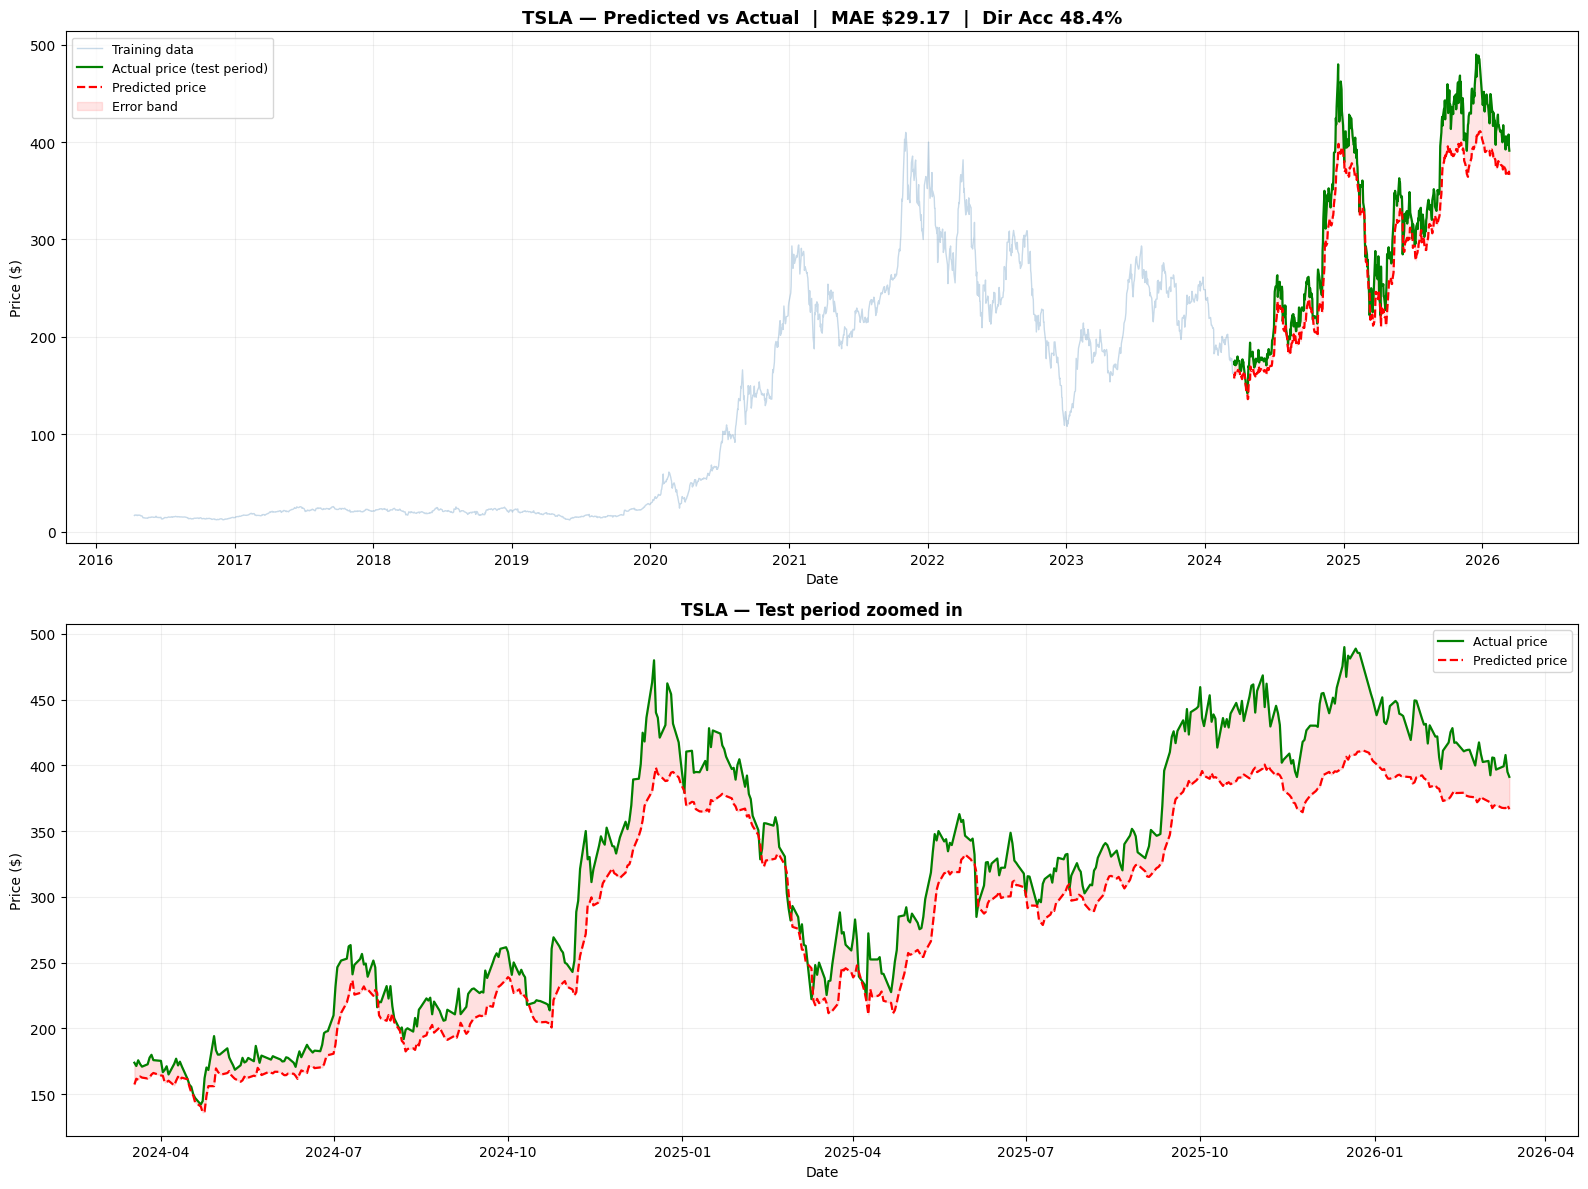


  NEXT-DAY PREDICTION — TSLA
------------------------------------------------
  Data up to  :  2026-03-13
  Predicting  :  2026-03-16
  Last close  :  $391.20
  Predicted   :  $365.03
  Direction   :  DOWN  $26.17
------------------------------------------------

  2-WEEK FORECAST — TSLA
------------------------------------------------
  Date            Predicted     Change   Dir
------------------------------------------------
  2026-03-16     $  365.03  ▼ $ 26.17
  2026-03-17     $  359.37  ▼ $  5.66
  2026-03-18     $  353.09  ▼ $  6.28
  2026-03-19     $  346.60  ▼ $  6.49
  2026-03-20     $  339.97  ▼ $  6.63
  2026-03-23     $  333.22  ▼ $  6.75
  2026-03-24     $  326.35  ▼ $  6.87
  2026-03-25     $  319.40  ▼ $  6.95
  2026-03-26     $  312.38  ▼ $  7.01
  2026-03-27     $  305.38  ▼ $  7.00
------------------------------------------------
  2-week outlook : DOWN  $85.82 total


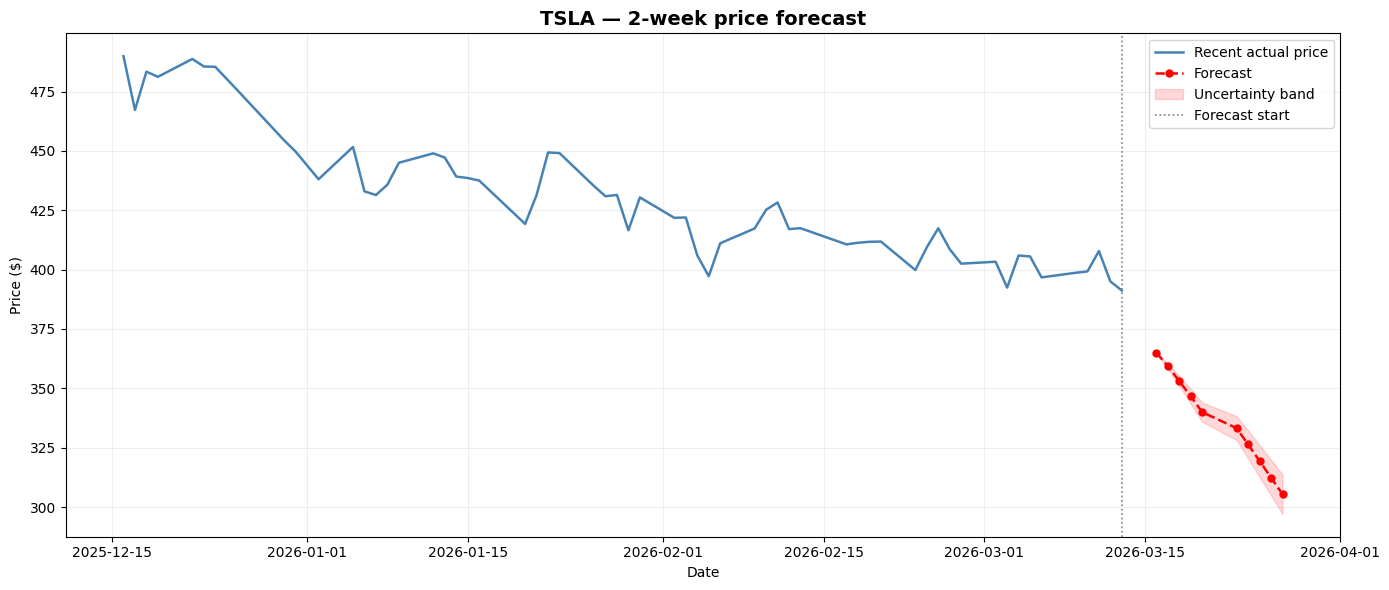

In [ ]:
# ============================================================
# CELL 10 — SINGLE STOCK DEEP DIVE
# Full analysis for one stock at a time:
#   - Predicted vs Actual chart (full test period)
#   - Performance metrics
#   - Next-day prediction
#   - 2-week forecast chart
#
# Change STOCK to any of the 10 loaded tickers:
# AAPL  AMZN  BAC  BLK  GOOGL  JPM  META  MSFT  NVDA  TSLA
# ============================================================

STOCK = 'TSLA'   # ← change this to any ticker

# ── helper: inverse-transform scaled Close values ─────────
def rescale_close(vals, scaler):
    dummy       = np.zeros((len(vals), scaler.n_features_in_))
    dummy[:, 0] = vals
    return scaler.inverse_transform(dummy)[:, 0]


def single_stock_analysis(ticker, model, scalers, dfs):
    if ticker not in scalers:
        print(f"'{ticker}' not found.")
        print(f"Available: {list(scalers.keys())}")
        return

    scaler    = scalers[ticker]
    df        = dfs[ticker]
    file_path = os.path.join(DRIVE_PATH, TICKERS[ticker])

    # ── 1. Rebuild test sequences for this stock ──────────
    _, X_te, _, y_te, _, _ = prepare_single_stock(file_path)

    y_pred_scaled = model.predict(X_te, verbose=0).flatten()
    y_pred        = rescale_close(y_pred_scaled, scaler)
    y_true        = rescale_close(y_te, scaler)

    # ── 2. Metrics ────────────────────────────────────────
    mae     = mean_absolute_error(y_true, y_pred)
    rmse    = np.sqrt(mean_squared_error(y_true, y_pred))
    mape    = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    dir_acc = np.mean(
        np.sign(np.diff(y_true)) == np.sign(np.diff(y_pred))
    ) * 100

    print("=" * 48)
    print(f"  DEEP DIVE — {ticker}")
    print("=" * 48)
    print(f"  MAE              : ${mae:.2f}")
    print(f"  RMSE             : ${rmse:.2f}")
    print(f"  Price accuracy   : {100 - mape:.2f}%")
    print(f"  Direction acc    : {dir_acc:.2f}%")
    print("=" * 48)

    # ── 3. Predicted vs Actual chart ──────────────────────
    test_dates = df.index[-len(y_true):]

    fig, axes = plt.subplots(2, 1, figsize=(16, 12))

    # Top chart — full history + test period
    ax1 = axes[0]
    ax1.plot(
        df.index[:-len(y_true)],
        df['Close'].iloc[:-len(y_true)],
        color='steelblue', alpha=0.3,
        linewidth=1, label='Training data'
    )
    ax1.plot(
        test_dates, y_true,
        color='green', linewidth=1.6,
        label='Actual price (test period)'
    )
    ax1.plot(
        test_dates, y_pred,
        color='red', linewidth=1.6,
        linestyle='dashed', label='Predicted price'
    )
    ax1.fill_between(
        test_dates, y_true, y_pred,
        alpha=0.1, color='red', label='Error band'
    )
    ax1.set_title(
        f"{ticker} — Predicted vs Actual  |  "
        f"MAE ${mae:.2f}  |  Dir Acc {dir_acc:.1f}%",
        fontsize=13, fontweight='bold'
    )
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Price ($)')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.2)

    # Bottom chart — zoom into test period only
    ax2 = axes[1]
    ax2.plot(
        test_dates, y_true,
        color='green', linewidth=1.6,
        label='Actual price'
    )
    ax2.plot(
        test_dates, y_pred,
        color='red', linewidth=1.6,
        linestyle='dashed', label='Predicted price'
    )
    ax2.fill_between(
        test_dates, y_true, y_pred,
        alpha=0.12, color='red'
    )
    ax2.set_title(
        f"{ticker} — Test period zoomed in",
        fontsize=12, fontweight='bold'
    )
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Price ($)')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

    # ── 4. Next-day prediction ────────────────────────────
    df_raw = pd.read_csv(file_path, index_col=0)
    df_raw.index = pd.to_datetime(df_raw.index)
    df_feat = build_features(df_raw)

    recent = df_feat[FEATURE_COLS].tail(LOOKBACK).values
    scaled = scaler.transform(recent).reshape(
        1, LOOKBACK, len(FEATURE_COLS)
    )

    pred_scaled = model.predict(scaled, verbose=0)[0, 0]
    next_price  = rescale_close(
        np.array([pred_scaled]), scaler
    )[0]

    last_close = df_feat['Close'].iloc[-1]
    last_date  = df_feat.index[-1]
    change     = next_price - last_close
    direction  = "UP" if change > 0 else "DOWN"

    next_date = last_date + timedelta(days=1)
    while next_date.weekday() >= 5:
        next_date += timedelta(days=1)

    print(f"\n  NEXT-DAY PREDICTION — {ticker}")
    print("-" * 48)
    print(f"  Data up to  :  {last_date.strftime('%Y-%m-%d')}")
    print(f"  Predicting  :  {next_date.strftime('%Y-%m-%d')}")
    print(f"  Last close  :  ${last_close:.2f}")
    print(f"  Predicted   :  ${next_price:.2f}")
    print(f"  Direction   :  {direction}  ${abs(change):.2f}")
    print("-" * 48)

    # ── 5. 2-week forecast ────────────────────────────────
    days   = 10
    window = scaler.transform(
        df_feat[FEATURE_COLS].tail(LOOKBACK).values
    ).reshape(1, LOOKBACK, len(FEATURE_COLS))

    future_scaled = []
    for _ in range(days):
        pred        = model.predict(window, verbose=0)[0, 0]
        future_scaled.append(pred)
        next_row    = window[0, -1, :].copy()
        next_row[0] = pred
        window = np.append(
            window[:, 1:, :],
            next_row.reshape(1, 1, -1),
            axis=1
        )

    dummy        = np.zeros((days, scaler.n_features_in_))
    dummy[:, 0]  = future_scaled
    forecast     = scaler.inverse_transform(dummy)[:, 0]

    future_dates = []
    current      = last_date
    while len(future_dates) < days:
        current += timedelta(days=1)
        if current.weekday() < 5:
            future_dates.append(current)

    # Print forecast table
    print(f"\n  2-WEEK FORECAST — {ticker}")
    print("-" * 48)
    print(f"  {'Date':<14} {'Predicted':>10} "
          f"{'Change':>10}  {'Dir':>4}")
    print("-" * 48)

    prev = last_close
    for date, price in zip(future_dates, forecast):
        change    = price - prev
        direction = "▲" if change >= 0 else "▼"
        print(f"  {date.strftime('%Y-%m-%d'):<14} "
              f"${price:>8.2f}  "
              f"{direction} ${abs(change):>6.2f}")
        prev = price

    total   = forecast[-1] - last_close
    outlook = "UP" if total >= 0 else "DOWN"
    print("-" * 48)
    print(f"  2-week outlook : {outlook}  ${abs(total):.2f} total")
    print("=" * 48)

    # Forecast chart
    history_dates  = df_feat.index[-60:]
    history_prices = df_feat['Close'].iloc[-60:].values
    uncertainty    = np.array([
        i * 0.003 * forecast[i] for i in range(days)
    ])

    plt.figure(figsize=(14, 6))
    plt.title(
        f'{ticker} — 2-week price forecast',
        fontsize=14, fontweight='bold'
    )
    plt.plot(
        history_dates, history_prices,
        label='Recent actual price',
        color='steelblue', linewidth=1.8
    )
    plt.plot(
        future_dates, forecast,
        label='Forecast', color='red',
        linestyle='dashed', linewidth=1.8,
        marker='o', markersize=5
    )
    plt.fill_between(
        future_dates,
        forecast - uncertainty,
        forecast + uncertainty,
        alpha=0.15, color='red',
        label='Uncertainty band'
    )
    plt.axvline(
        x=last_date, color='gray',
        linestyle=':', linewidth=1.2,
        label='Forecast start'
    )
    plt.xlabel('Date')
    plt.ylabel('Price ($)')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()


# ── Run it ────────────────────────────────────────────────
single_stock_analysis(STOCK, model, scalers, dfs)

In [ ]:
# Run this immediately to save your work
import pickle, os

MODEL_FILE   = os.path.join(DRIVE_PATH, 'multi_stock_BiLSTM_GRU.keras')
SCALERS_FILE = os.path.join(DRIVE_PATH, 'multi_stock_scalers.pkl')

model.save(MODEL_FILE)
with open(SCALERS_FILE, 'wb') as f:
    pickle.dump(scalers, f)

print(f"✅ Model saved   → {MODEL_FILE}")
print(f"✅ Scalers saved → {SCALERS_FILE}")

✅ Model saved   → /content/drive/MyDrive/Colab Notebooks/data1010/multi_stock_BiLSTM_GRU.keras
✅ Scalers saved → /content/drive/MyDrive/Colab Notebooks/data1010/multi_stock_scalers.pkl
